<a href="https://colab.research.google.com/github/Adj95/python_dsc/blob/main/Bagging_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [82]:
import numpy as np
import pandas as pd
import seaborn as sns



In [83]:
df = pd.read_csv("/content/Iris (1).csv")

In [84]:
df = df.drop(columns = ['Id' , 'PetalLengthCm' , 'PetalWidthCm'])

In [85]:
df.head()

,SepalLengthCm,SepalWidthCm,Species
0,5.1,3.5,Iris-setosa
1,4.9,3.0,Iris-setosa
2,4.7,3.2,Iris-setosa
3,4.6,3.1,Iris-setosa
4,5.0,3.6,Iris-setosa


In [86]:
df =(df[df['Species'] != 'Iris-setosa'])

In [87]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])
df.sample(10)

,SepalLengthCm,SepalWidthCm,Species
99,5.7,2.8,0
138,6.0,3.0,1
111,6.4,2.7,1
87,6.3,2.3,0
86,6.7,3.1,0
113,5.7,2.5,1
94,5.6,2.7,0
58,6.6,2.9,0
128,6.4,2.8,1
98,5.1,2.5,0


In [88]:
df = df.sample(100)

In [89]:
df_train = df.iloc[:60 , :].sample(10)
df_val = df.iloc[60:80 , :].sample(5)
df_test = df.iloc[80: , :].sample(5)

In [90]:
x_test = df_val.iloc[: , 0:2].values
y_tets= df_val.iloc[: , -1].values

In [91]:
df_bag = df_train .sample(8, replace = True)
x = df_bag.iloc[: , 0:2]
y = df_bag.iloc[: , -1]

df_bag

,SepalLengthCm,SepalWidthCm,Species
78,6.0,2.9,0
92,5.8,2.6,0
92,5.8,2.6,0
81,5.5,2.4,0
81,5.5,2.4,0
144,6.7,3.3,1
92,5.8,2.6,0
120,6.9,3.2,1


**BOOTSTRAPPING**

In [92]:
from sklearn.tree import DecisionTreeClassifier , plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [93]:
dt_bag1= DecisionTreeClassifier()

In [94]:
def evaluate(clf,x,y):
  clf.fit(x,y)
  plot_tree(clf)
  plot_decision_regions( x.values , y.values , clf = clf , legend = 2)
  y_pred = clf.predict(x_test)
  print(accuracy_score(y_tets , y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


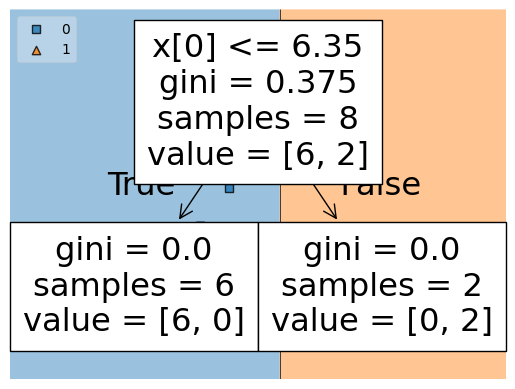

In [95]:
evaluate(dt_bag1,x,y)

In [96]:
df_bag = df_train .sample(8, replace = True)
x = df_bag.iloc[: , 0:2]
y = df_bag.iloc[: , -1]

df_bag

,SepalLengthCm,SepalWidthCm,Species
81,5.5,2.4,0
104,6.5,3.0,1
81,5.5,2.4,0
81,5.5,2.4,0
105,7.6,3.0,1
105,7.6,3.0,1
119,6.0,2.2,1
92,5.8,2.6,0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


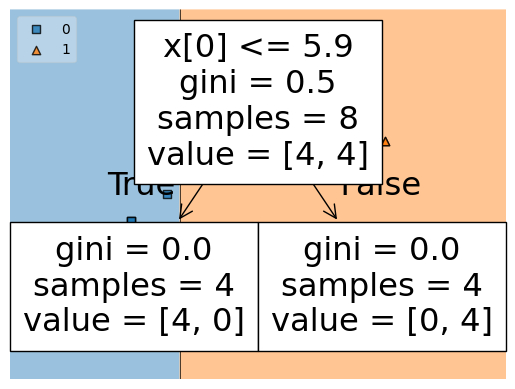

In [97]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,x,y)

In [98]:
df_bag = df_train .sample(8, replace = True)
x = df_bag.iloc[: , 0:2]
y = df_bag.iloc[: , -1]

df_bag

,SepalLengthCm,SepalWidthCm,Species
120,6.9,3.2,1
104,6.5,3.0,1
110,6.5,3.2,1
119,6.0,2.2,1
104,6.5,3.0,1
144,6.7,3.3,1
119,6.0,2.2,1
81,5.5,2.4,0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


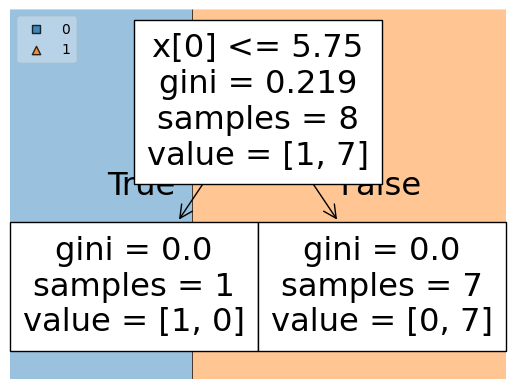

In [99]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,x,y)

In [100]:
df_test.head()

,SepalLengthCm,SepalWidthCm,Species
84,5.4,3.0,0
101,5.8,2.7,1
56,6.3,3.3,0
102,7.1,3.0,1
118,7.7,2.6,1


**AGGREGATING**

In [101]:
print("predictor 1:" ,dt_bag1.predict(np.array([5.5,2.63]).reshape(1,2)))
print("predictor 2:" ,dt_bag2.predict(np.array([5.5,2.63]).reshape(1,2)))
print("predictor 3:" ,dt_bag3.predict(np.array([5.5,2.63]).reshape(1,2)))

predictor 1: [0]
predictor 2: [0]
predictor 3: [0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [1]:
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm  import SVC
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier

In [2]:
x,y = make_classification(n_samples= 10000 , n_features= 15 , n_informative= 3 )

In [3]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size= 0.2)

In [5]:
dt = DecisionTreeClassifier(random_state = 42 )
dt.fit(x_train,y_train)
y_pred = dt.predict(x_test)
print(accuracy_score(y_test,y_pred))

0.855


In [6]:
bag = BaggingClassifier(
    estimator = DecisionTreeClassifier(),
    n_estimators = 500,
    max_samples = 0.25,
    bootstrap = True,
    random_state = 42
)



In [8]:
bag.fit(x_train,y_train)
y_pred1= bag.predict(x_test)
print(accuracy_score(y_test,y_pred1))

0.8955
